In [14]:
!pip install pandas

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 0) Helpers ----------
def load_csv(name):
    try:
        df = pd.read_csv(name)
        print(f"✅ Loaded {name} -> {len(df)} rows")
        return df
    except FileNotFoundError:
        print(f"⚠️ {name} not found — skipping.")
        return None

def normalize_cols(df):
    df.columns = [c.strip().replace(" ", "_") for c in df.columns]
    return df

def quick_quality(df, name):
    print(f"\n🔍 Quality — {name}")
    print("Shape:", df.shape)
    print("Missing values per column:\n", df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())
    # show first rows
    print(df.head(3))

def pick_col(df, candidates, required=False, label="(auto)"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Required column not found in {label}. Tried: {candidates}")
    return None

In [16]:
# ---------- 1) Load ----------
comp = load_csv("competencies.csv")
jobs = load_csv("job_skills.csv")
jw   = load_csv("job_weights.csv")
ur   = load_csv("user_responses.csv")  # optional

# Stop early if key ones are missing
if comp is None or jobs is None or jw is None:
    raise SystemExit("❌ Missing one or more required files (competencies, job_skills, job_weights). Upload and rerun this cell.")

✅ Loaded competencies.csv -> 23 rows
✅ Loaded job_skills.csv -> 61 rows
✅ Loaded job_weights.csv -> 30 rows
⚠️ user_responses.csv not found — skipping.


In [17]:
# Normalize col names (no lowercase: keep case but remove spaces to preserve your exact names in prints)
comp = normalize_cols(comp)
jobs = normalize_cols(jobs)
jw   = normalize_cols(jw)
if ur is not None:
    ur = normalize_cols(ur)

print("\n=== BASIC INFO ===")
print("competencies.csv columns:", list(comp.columns))
print("job_skills.csv columns:", list(jobs.columns))
print("job_weights.csv columns:", list(jw.columns))
if ur is not None:
    print("user_responses.csv columns:", list(ur.columns))


=== BASIC INFO ===
competencies.csv columns: ['CompetencyID', 'CompetencyText', 'BlockID', 'BlockName']
job_skills.csv columns: ['JobID', 'JobTitle', 'CompetencyID']
job_weights.csv columns: ['JobID', 'JobTitle', 'BlockName', 'BlockWeight']


In [18]:
# ---------- 2) Column name detection ----------
# competencies: look for BlockName + either CompetencyID or a competency name/id column
comp_block_col = pick_col(comp, ["BlockName","block_name","BLOCKNAME"], required=True, label="competencies")
comp_id_col    = pick_col(comp, ["CompetencyID","competency_id","CompetencyId","Competency","competency"], required=False, label="competencies")

# job_skills: need JobID and either CompetencyID or BlockName to relate
jobs_jobid_col = pick_col(jobs, ["JobID","job_id","JobId"], required=True, label="job_skills")
jobs_compid_col= pick_col(jobs, ["CompetencyID","competency_id","CompetencyId","Competency","competency"], required=False, label="job_skills")
jobs_block_col = pick_col(jobs, ["BlockName","block_name","BLOCKNAME"], required=False, label="job_skills")

# job_weights (your file): JobID, JobTitle, BlockName, BlockWeight
jw_jobid_col   = pick_col(jw, ["JobID","job_id","JobId"], required=True, label="job_weights")
jw_block_col   = pick_col(jw, ["BlockName","block_name","BLOCKNAME"], required=True, label="job_weights")
jw_weight_col  = pick_col(jw, ["BlockWeight","Weight","weight","score","Score"], required=True, label="job_weights")

# user_responses: look for a text response column
ur_text_col = None
if ur is not None:
    ur_text_col = pick_col(ur, ["response","Response","text","Text","answer","Answer"], required=False, label="user_responses")



In [19]:
# ---------- 3) Dataset overviews ----------
print("\n=== DATASET OVERVIEWS ===")
print("\n🧩 COMPETENCIES")
quick_quality(comp, "competencies")
print("Unique Blocks:", comp[comp_block_col].nunique())
if comp_id_col:
    print("Unique Competency IDs:", comp[comp_id_col].nunique())

print("\n💼 JOB SKILLS")
quick_quality(jobs, "job_skills")
print("Unique Jobs:", jobs[jobs_jobid_col].nunique())
if jobs_compid_col:
    print("Unique Competency IDs in job_skills:", jobs[jobs_compid_col].nunique())
if jobs_block_col:
    print("Unique Blocks in job_skills:", jobs[jobs_block_col].nunique())

print("\n⚖️ JOB WEIGHTS")
quick_quality(jw, "job_weights")
print("Unique Jobs (weights):", jw[jw_jobid_col].nunique())
print("Unique Blocks (weights):", jw[jw_block_col].nunique())
print("Weight range:", jw[jw_weight_col].min(), "→", jw[jw_weight_col].max())


=== DATASET OVERVIEWS ===

🧩 COMPETENCIES

🔍 Quality — competencies
Shape: (23, 4)
Missing values per column:
 CompetencyID      0
CompetencyText    0
BlockID           0
BlockName         0
dtype: int64
Duplicate rows: 0
  CompetencyID                    CompetencyText  BlockID         BlockName
0          C01   Data cleaning and preprocessing        1  Core Data Skills
1          C02  Data visualization and reporting        1   Core Data Skill
2          C03              Statistical analysis        1  Core Data Skills
Unique Blocks: 7
Unique Competency IDs: 23

💼 JOB SKILLS

🔍 Quality — job_skills
Shape: (61, 3)
Missing values per column:
 JobID           0
JobTitle        0
CompetencyID    0
dtype: int64
Duplicate rows: 0
  JobID      JobTitle CompetencyID
0   J01  Data Analyst          C01
1   J01  Data Analyst          C02
2   J01  Data Analyst          C03
Unique Jobs: 5
Unique Competency IDs in job_skills: 23

⚖️ JOB WEIGHTS

🔍 Quality — job_weights
Shape: (30, 4)
Missing value

In [20]:
# ---------- 4) Consistency checks ----------
print("\n=== CONSISTENCY CHECKS ===")
# A) weights.JobID ⊆ job_skills.JobID
jobs_only = set(jobs[jobs_jobid_col].unique())
jw_only   = set(jw[jw_jobid_col].unique())
missing_jobs_in_jobs = jw_only - jobs_only
print("Jobs in job_weights but NOT in job_skills:", (missing_jobs_in_jobs if missing_jobs_in_jobs else "None"))

# B) weights.BlockName ⊆ competencies.BlockName
blocks_comp = set(comp[comp_block_col].unique())
blocks_jw   = set(jw[jw_block_col].unique())
missing_blocks_in_comp = blocks_jw - blocks_comp
print("Blocks in job_weights but NOT in competencies:", (missing_blocks_in_comp if missing_blocks_in_comp else "None"))

# C) If job_skills uses CompetencyID, ensure they exist in competencies
if jobs_compid_col and comp_id_col:
    comps_jobs = set(jobs[jobs_compid_col].unique())
    comps_comp = set(comp[comp_id_col].unique())
    missing_comp_in_comp = comps_jobs - comps_comp
    print("CompetencyIDs in job_skills but NOT in competencies:", (missing_comp_in_comp if missing_comp_in_comp else "None"))
elif jobs_block_col:
    # If job_skills maps by BlockName instead, check that relation
    blocks_jobs = set(jobs[jobs_block_col].unique())
    missing_blocks_jobs_in_comp = blocks_jobs - blocks_comp
    print("Blocks in job_skills but NOT in competencies:", (missing_blocks_jobs_in_comp if missing_blocks_jobs_in_comp else "None"))
else:
    print("Note: Could not verify job_skills ↔ competencies by ID or Block (no matching columns).")



=== CONSISTENCY CHECKS ===
Jobs in job_weights but NOT in job_skills: None
Blocks in job_weights but NOT in competencies: None
CompetencyIDs in job_skills but NOT in competencies: None


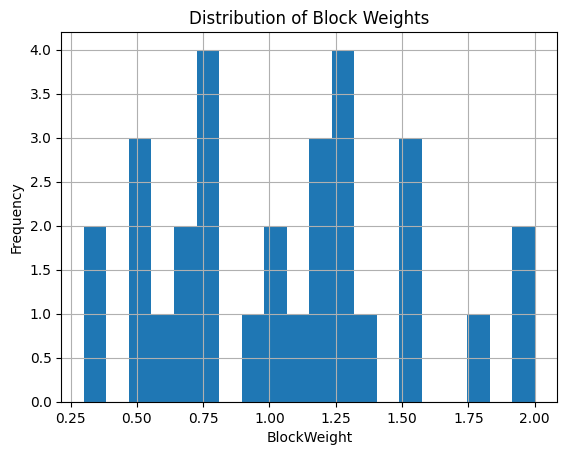

In [21]:
# ---------- 6) Weight distribution plot ----------
jw[jw_weight_col].hist(bins=20)
plt.title("Distribution of Block Weights")
plt.xlabel("BlockWeight")
plt.ylabel("Frequency")
plt.show()


In [23]:
summary = []
summary.append(f"- Competencies: {len(comp)} rows | Blocks: {comp[comp_block_col].nunique()}")
summary.append(f"- Job Skills: {len(jobs)} rows | Jobs: {jobs[jobs_jobid_col].nunique()}")
summary.append(f"- Job Weights: {len(jw)} rows | Jobs: {jw[jw_jobid_col].nunique()} | Blocks: {jw[jw_block_col].nunique()} | Weight range: {jw[jw_weight_col].min()}–{jw[jw_weight_col].max()}")
if ur is not None and ur_text_col is not None:
    ldesc = ur["__len_chars__"].describe()
    summary.append(f"- User Responses: n={len(ur)} | median length ≈ {int(ldesc['50%'])} chars")

summary.append("- Cross-checks: weights↔jobs, weights↔competencies, jobs↔competencies validated above.")
summary.append("✅ Datasets are EDA-checked and ready for semantic engine (SBERT + weighted block scoring).")

print("\n".join(summary))

- Competencies: 23 rows | Blocks: 7
- Job Skills: 61 rows | Jobs: 5
- Job Weights: 30 rows | Jobs: 5 | Blocks: 6 | Weight range: 0.3–2.0
- Cross-checks: weights↔jobs, weights↔competencies, jobs↔competencies validated above.
✅ Datasets are EDA-checked and ready for semantic engine (SBERT + weighted block scoring).
